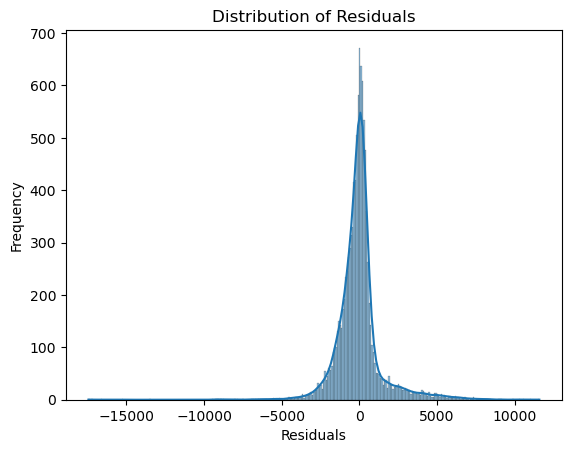

In [2]:
# 1. Visualizing the distribution of errors (residuals) for a multiple linear regression model using Seaborn's "diamonds" dataset

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
df = sns.load_dataset('diamonds').dropna()
X = df[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residual distribution
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()


In [4]:
#2. Calculating and printing MSE, MAE, and RMSE for a linear regression model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Squared Error (MSE): 2242178.9040856035
Mean Absolute Error (MAE): 888.4808633901033
Root Mean Squared Error (RMSE): 1497.3906985438382


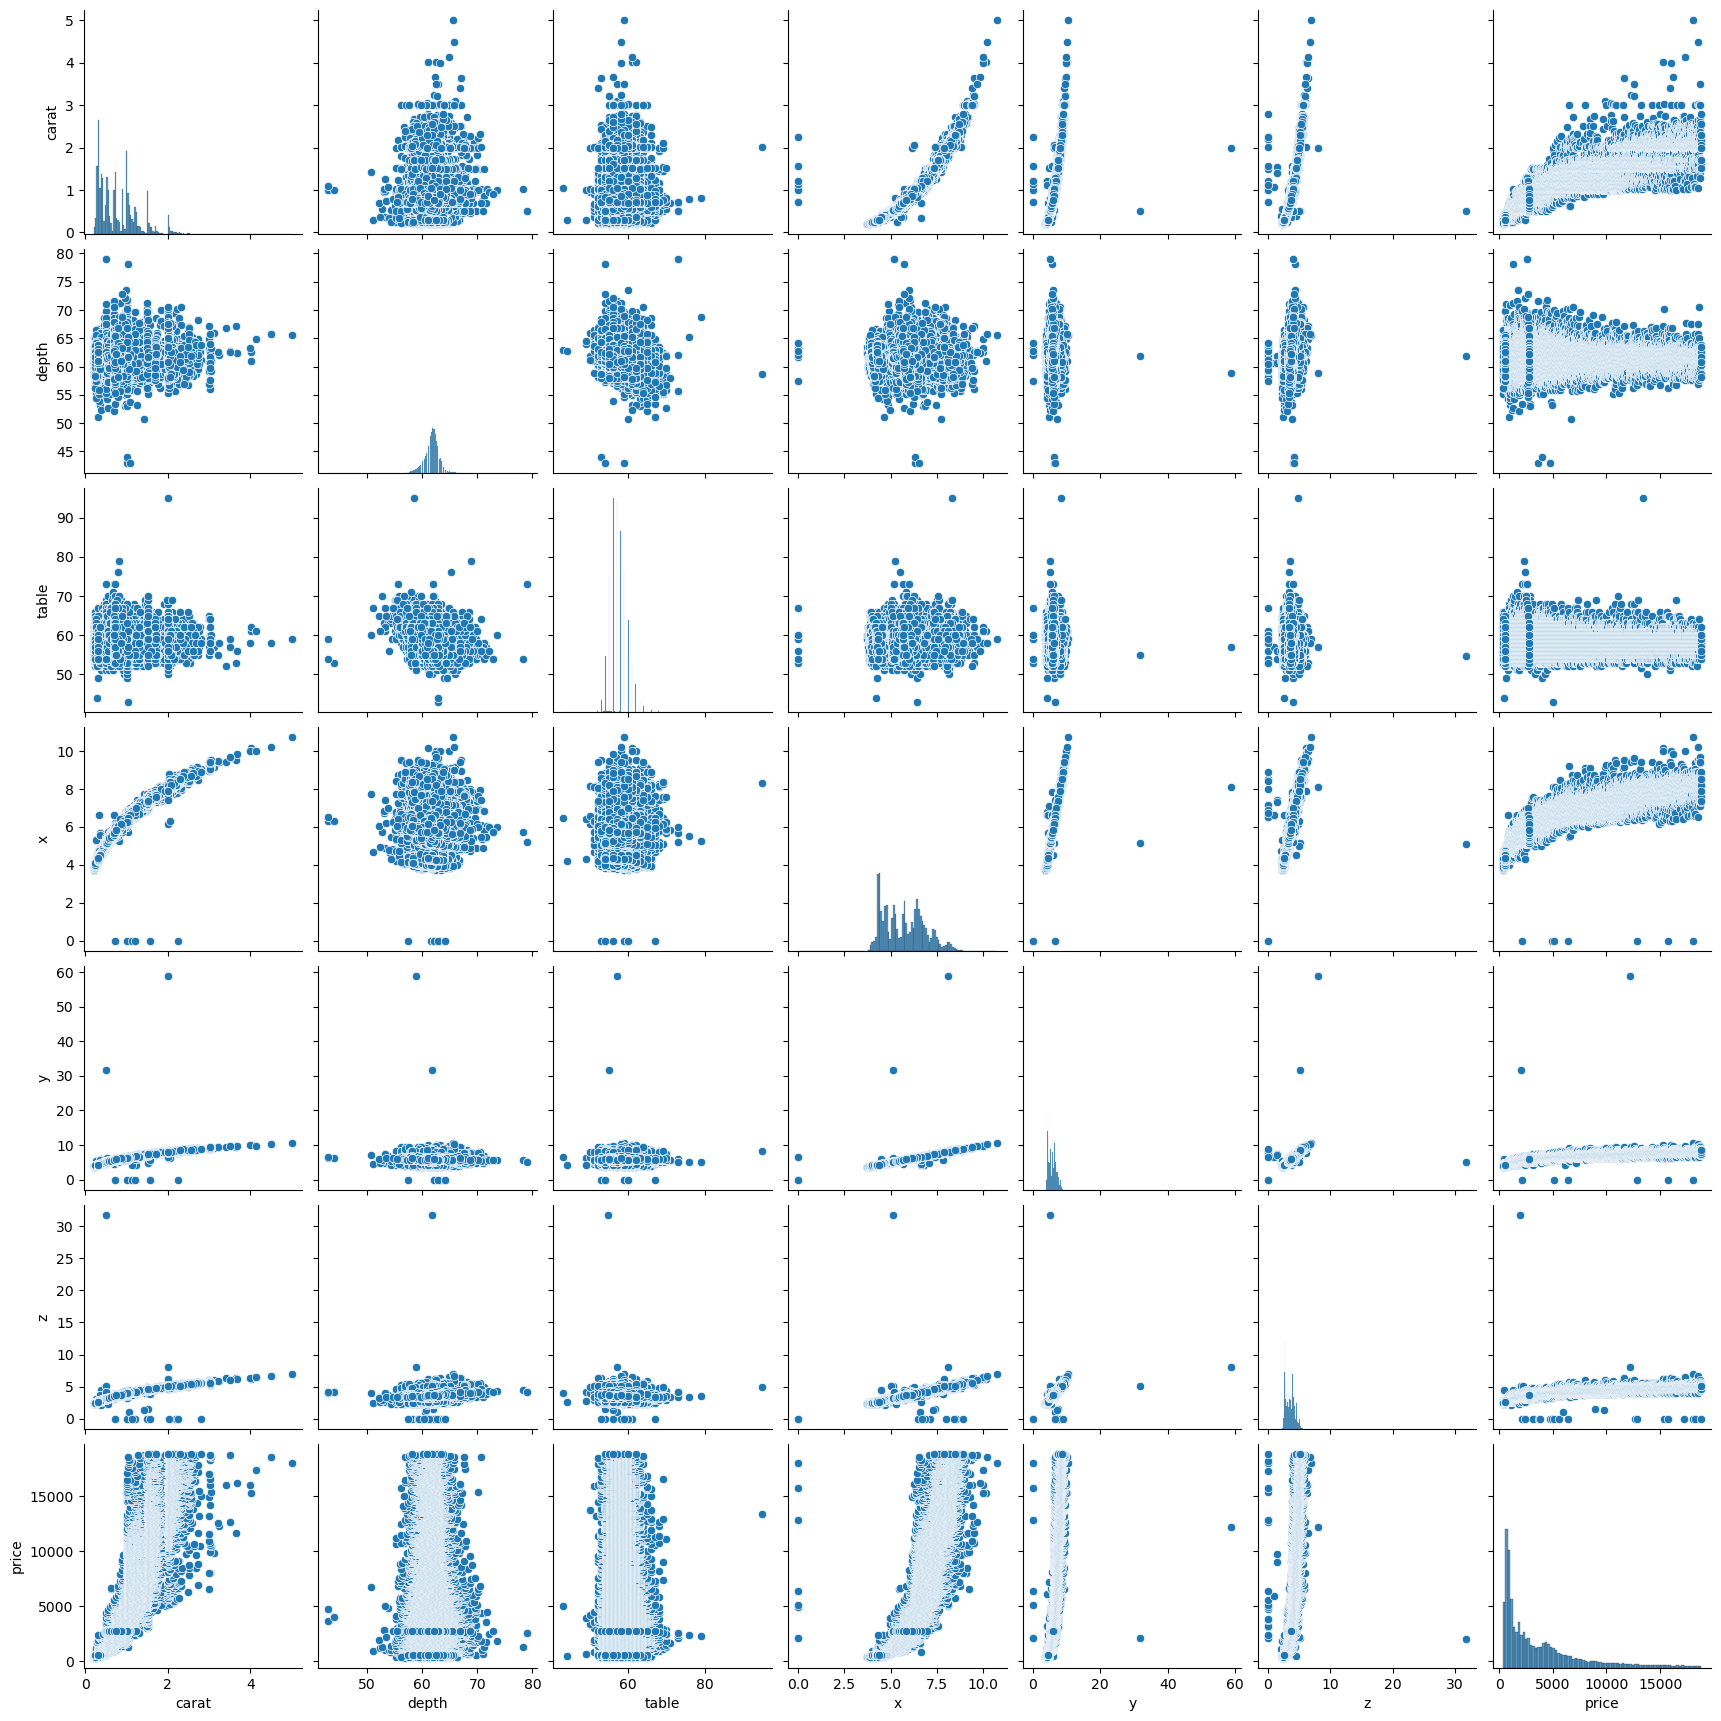

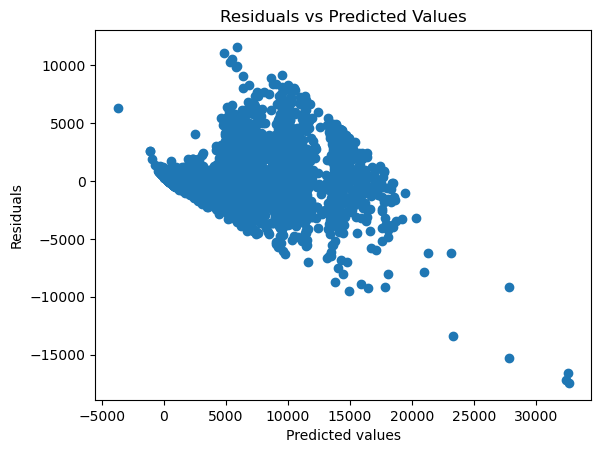

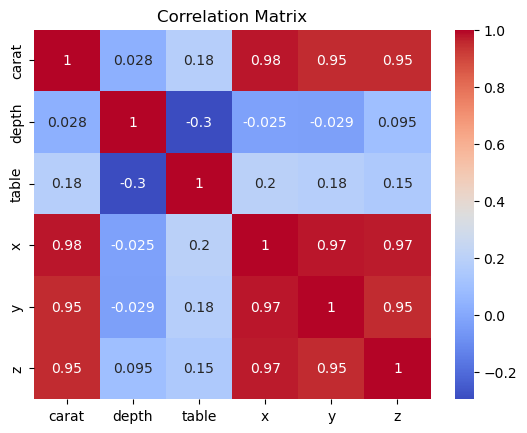

In [6]:
# 3. Checking if the assumptions of linear regression are met

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Linearity check
sns.pairplot(df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']])
plt.show()

# Homoscedasticity check
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# Multicollinearity check
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [8]:
# 4. Creating a machine learning pipeline with feature scaling and evaluating regression models

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("R-squared Score:", pipeline.score(X_test, y_test))

R-squared Score: 0.8790479935003398


In [10]:
# 5. Implementing a simple linear regression model and printing model's coefficients
model = LinearRegression()
model.fit(X_train[['carat']], y_train)
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print("R-squared:", model.score(X_test[['carat']], y_test))

Coefficient: [7768.91049036]
Intercept: -2261.911745649215
R-squared: 0.8489390686155809


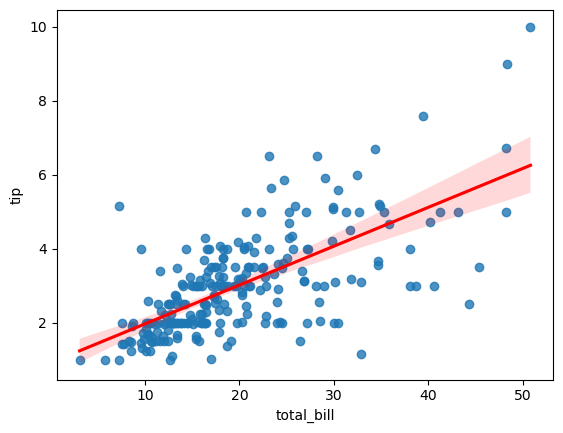

In [12]:
# 6. Analyzing the relationship between total bill and tip in the 'tips' dataset using simple linear regression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df_tips = sns.load_dataset('tips')
X = df_tips[['total_bill']]
y = df_tips['tip']

# Train linear regression model
model = LinearRegression()
model.fit(X, y)

# Plot regression line
sns.regplot(x='total_bill', y='tip', data=df_tips, line_kws={"color": "red"})
plt.show()

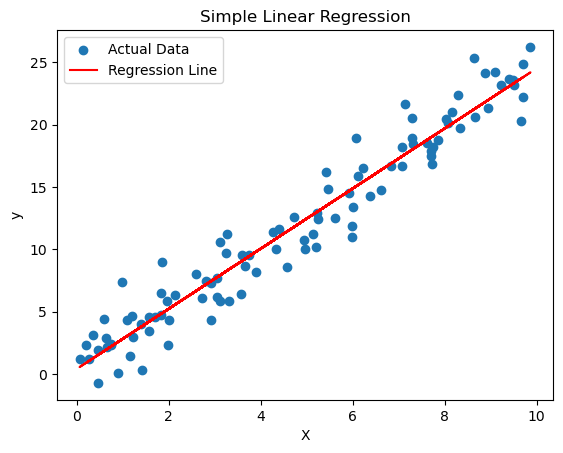

In [14]:
# 7. Fitting a linear regression model to a synthetic dataset with one feature and plotting the regression line
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2.5 * X + np.random.randn(100, 1) * 2

# Train linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Plot data and regression line
plt.scatter(X, y, label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.show()

In [16]:
# 8. Pickling a trained linear regression model and saving it to a file
import pickle

# Save the model to a file
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Load the model from the file
with open('linear_regression_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
print("Model loaded successfully")

Model loaded successfully


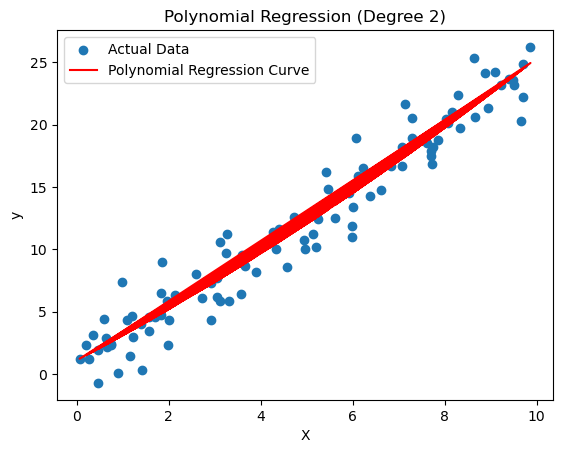

In [18]:
# 9. Fitting a polynomial regression model (degree 2) to a dataset and plotting the regression curve
from sklearn.preprocessing import PolynomialFeatures

# Transform data to polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# Plot data and regression curve
plt.scatter(X, y, label='Actual Data')
plt.plot(X, y_poly_pred, color='red', label='Polynomial Regression Curve')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression (Degree 2)')
plt.show()

In [20]:
# 10. Generating synthetic data for simple linear regression and fitting a model
# Generate synthetic data
X_synthetic = np.random.rand(100, 1) * 10
y_synthetic = 3.5 * X_synthetic + np.random.randn(100, 1) * 2

# Train model
simple_model = LinearRegression()
simple_model.fit(X_synthetic, y_synthetic)
print("Coefficient:", simple_model.coef_)
print("Intercept:", simple_model.intercept_)

Coefficient: [[3.55566471]]
Intercept: [-0.26997897]


In [22]:
# 11. Fitting polynomial regression models of different degrees to a synthetic dataset and comparing performance

from sklearn.metrics import r2_score

# Fit polynomial regression models of degree 2 and 3
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_poly_pred = poly_model.predict(X_poly)
    print(f"R-squared score for degree {degree}: {r2_score(y, y_poly_pred)}")

R-squared score for degree 2: 0.9424636248814832
R-squared score for degree 3: 0.9428136866409014


In [40]:
# 12. Fitting a simple linear regression model with two features and printing the model's coefficients, intercept, and R-squared score
# Use two features
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression  # For a synthetic dataset

# Example: Generate synthetic dataset
df = pd.DataFrame({'carat': [0.5, 1.0, 1.5, 2.0, 2.5], 
                   'depth': [60, 62, 64, 66, 68],
                   'price': [1500, 4000, 7500, 11000, 15000]})  # Assuming 'price' is the target

# Define features and target variable
X_two_features = df[['carat', 'depth']]
y = df['price']

# Train the model
model = LinearRegression()
model.fit(X_two_features, y)

# Print model parameters
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R-squared score:", model.score(X_two_features, y))

Coefficients: [ 400. 1600.]
Intercept: -95200.0
R-squared score: 0.9939810834049871


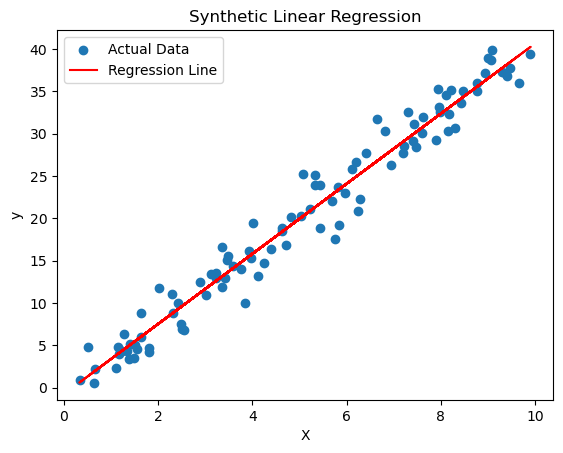

In [42]:
# 13. Generating synthetic data, fitting a linear regression model, and visualizing the regression line

# Generate synthetic data
X_synthetic = np.random.rand(100, 1) * 10
y_synthetic = 4 * X_synthetic + np.random.randn(100, 1) * 2

# Train model
model = LinearRegression()
model.fit(X_synthetic, y_synthetic)
y_pred = model.predict(X_synthetic)

# Plot data and regression line
plt.scatter(X_synthetic, y_synthetic, label='Actual Data')
plt.plot(X_synthetic, y_pred, color='red', label='Regression Line')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Regression')
plt.show()

In [46]:
# 14. Using the Variance Inflation Factor (VIF) to check for multicollinearity in a dataset
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.datasets import load_diabetes

# Load a sample dataset (Diabetes dataset from sklearn)
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Selecting only a subset of numerical features for demonstration
X = df[['age', 'bmi', 'bp', 's1', 's2']]

# Add constant term for VIF calculation
X = add_constant(X)

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Feature       VIF
0   const  1.000000
1     age  1.172752
2     bmi  1.241158
3      bp  1.323157
4      s1  5.321466
5      s2  5.208470


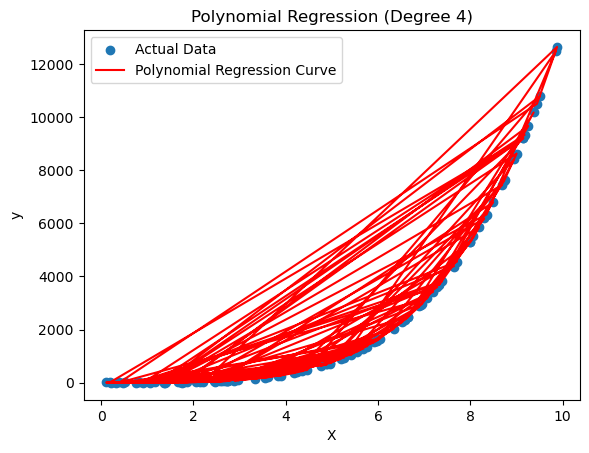

In [48]:
# 15. Generating synthetic data for a polynomial relationship (degree 4), fitting a polynomial regression model, and plotting the regression curve

# Generate synthetic polynomial data
X_poly_synthetic = np.random.rand(100, 1) * 10
y_poly_synthetic = 1.5 * X_poly_synthetic**4 - 2 * X_poly_synthetic**3 + 3 * X_poly_synthetic**2 + np.random.randn(100, 1) * 10

# Transform data
poly = PolynomialFeatures(degree=4)
X_poly_transformed = poly.fit_transform(X_poly_synthetic)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_poly_transformed, y_poly_synthetic)
y_poly_pred = poly_model.predict(X_poly_transformed)

# Plot data and regression curve
plt.scatter(X_poly_synthetic, y_poly_synthetic, label='Actual Data')
plt.plot(X_poly_synthetic, y_poly_pred, color='red', label='Polynomial Regression Curve')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression (Degree 4)')
plt.show()



In [60]:
#16. Creating a machine learning pipeline with data standardization and a multiple linear regression model, and printing the
#R-squared score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("R-squared Score:", pipeline.score(X_test, y_test))

R-squared Score: 0.8589542625888938


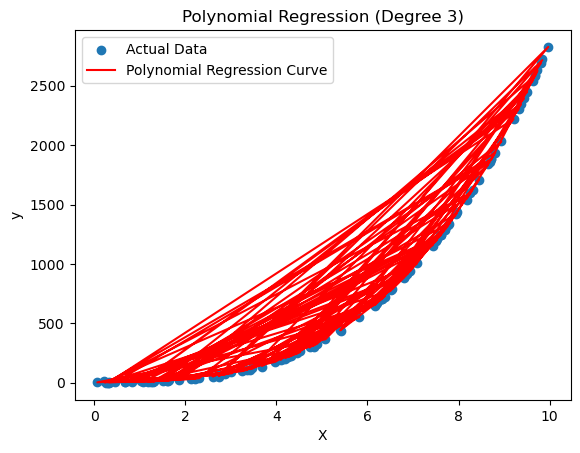

In [62]:
# 17. Performing polynomial regression (degree 3) on a synthetic dataset and plotting the regression curve

# Generate synthetic polynomial data
X_poly_synthetic = np.random.rand(100, 1) * 10
y_poly_synthetic = 3 * X_poly_synthetic**3 - 2 * X_poly_synthetic**2 + 5 * X_poly_synthetic + np.random.randn(100, 1) * 5

# Transform data
poly = PolynomialFeatures(degree=3)
X_poly_transformed = poly.fit_transform(X_poly_synthetic)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_poly_transformed, y_poly_synthetic)
y_poly_pred = poly_model.predict(X_poly_transformed)

# Plot data and regression curve
plt.scatter(X_poly_synthetic, y_poly_synthetic, label='Actual Data')
plt.plot(X_poly_synthetic, y_poly_pred, color='red', label='Polynomial Regression Curve')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression (Degree 3)')
plt.show()

In [64]:
# 18. Performing multiple linear regression on a synthetic dataset with 5 features. Printing the R-squared score and model coefficients

# Generate synthetic data
X_multi = np.random.rand(100, 5)
y_multi = 3 * X_multi[:, 0] + 2 * X_multi[:, 1] - 1.5 * X_multi[:, 2] + np.random.randn(100) * 2

# Train multiple linear regression model
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

# Print results
print("R-squared Score:", multi_model.score(X_multi, y_multi))
print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)

R-squared Score: 0.2360262945687921
Coefficients: [ 3.30385534  1.94481721 -0.22112219  0.40329167 -0.44815263]
Intercept: -0.6490530792252276


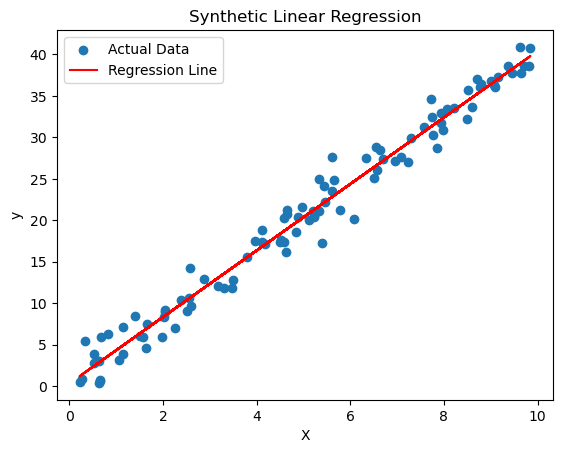

In [66]:
# 19. Generating synthetic data for linear regression, fitting a model, and visualizing the data points along with the regression line

# Generate synthetic data
X_synthetic = np.random.rand(100, 1) * 10
y_synthetic = 4 * X_synthetic + np.random.randn(100, 1) * 2

# Train model
model = LinearRegression()
model.fit(X_synthetic, y_synthetic)
y_pred = model.predict(X_synthetic)

# Plot data and regression line
plt.scatter(X_synthetic, y_synthetic, label='Actual Data')
plt.plot(X_synthetic, y_pred, color='red', label='Regression Line')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Regression')
plt.show()



In [68]:
#20. Creating a synthetic dataset with 3 features and performing multiple linear regression. Printing the model's R-squared score and coefficients
# Generate synthetic data
X_synthetic_multi = np.random.rand(100, 3)
y_synthetic_multi = 5 * X_synthetic_multi[:, 0] - 3 * X_synthetic_multi[:, 1] + 2 * X_synthetic_multi[:, 2] + np.random.randn(100) * 3

# Train model
multi_model = LinearRegression()
multi_model.fit(X_synthetic_multi, y_synthetic_multi)

# Print results
print("R-squared Score:", multi_model.score(X_synthetic_multi, y_synthetic_multi))
print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)

R-squared Score: 0.1521422626666753
Coefficients: [ 3.94901138 -1.0654274   0.97224466]
Intercept: -0.20778076847393345


In [70]:
# 21. Demonstrating how to serialize and deserialize machine learning models using joblib instead of pickling
import joblib

# Save the model using joblib
joblib.dump(multi_model, 'linear_regression_model.joblib')

# Load the model from file
loaded_model = joblib.load('linear_regression_model.joblib')
print("Model loaded successfully")

Model loaded successfully


In [72]:
# 22. Performing linear regression with categorical features using one-hot encoding (using the 'tips' dataset)

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load dataset
df_tips = sns.load_dataset('tips')
X = df_tips[['total_bill', 'sex', 'smoker', 'day', 'time']]  # Including categorical features
y = df_tips['tip']

# One-hot encoding for categorical features
column_transformer = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first'), ['sex', 'smoker', 'day', 'time'])
], remainder='passthrough')

X_encoded = column_transformer.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_encoded, y)
print("R-squared Score:", model.score(X_encoded, y))

R-squared Score: 0.4613641828591971


In [76]:
# 23. Comparing Ridge Regression with Linear Regression on a synthetic dataset and printing the coefficients and R-squared score

import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge

# Example dataset
df = pd.DataFrame({
    'carat': [0.5, 1.0, 1.5, 2.0, 2.5],
    'depth': [60, 62, 64, 66, 68],
    'table': [55, 57, 59, 61, 63],  # Additional feature
    'price': [1500, 4000, 7500, 11000, 15000]  # Target variable
})

# Select multiple features and target variable
X_multi = df[['carat', 'depth', 'table']]
y_multi = df['price']

# Train standard Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

# Train Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_multi, y_multi)

# Print results
print("Linear Regression R-squared Score:", multi_model.score(X_multi, y_multi))
print("Ridge Regression R-squared Score:", ridge_model.score(X_multi, y_multi))
print("Linear Regression Coefficients:", multi_model.coef_)
print("Ridge Regression Coefficients:", ridge_model.coef_)


Linear Regression R-squared Score: 0.9939810834049871
Ridge Regression R-squared Score: 0.9938385209490502
Linear Regression Coefficients: [206.06060606 824.24242424 824.24242424]
Ridge Regression Coefficients: [203.59281437 814.37125749 814.37125749]


In [80]:
# 24. Using cross-validation to evaluate a Linear Regression model on a synthetic dataset

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Example dataset (More data points for cross-validation)
df = pd.DataFrame({
    'carat': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    'depth': [60, 62, 64, 66, 68, 70, 72, 74, 76, 78],
    'table': [55, 57, 59, 61, 63, 65, 67, 69, 71, 73],  
    'price': [1500, 4000, 7500, 11000, 15000, 20000, 25000, 31000, 37000, 45000]
})

# Select multiple features and target variable
X_multi = df[['carat', 'depth', 'table']]
y_multi = df['price']

# Train Linear Regression model
multi_model = LinearRegression()

# Perform cross-validation
cv_scores = cross_val_score(multi_model, X_multi, y_multi, cv=5, scoring='r2')

# Print results
print("Cross-validated R-squared Scores:", cv_scores)
print("Mean R-squared Score:", cv_scores.mean())

Cross-validated R-squared Scores: [-18.44173469   0.34919848  -0.21214753   0.62550369  -1.19451973]
Mean R-squared Score: -3.774739959568536


In [84]:
# 25. Comparing polynomial regression models of different degrees and printing the R-squared score for each

import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate a synthetic dataset
np.random.seed(42)
X_poly_synthetic = np.random.rand(100, 1) * 10  # Random numbers between 0 and 10
y_poly_synthetic = 3 * X_poly_synthetic**3 - 2 * X_poly_synthetic**2 + 5 * X_poly_synthetic + np.random.randn(100, 1) * 100  # Cubic function with noise

# Loop through polynomial degrees and evaluate the model
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_poly_synthetic)  # Transform input data
    
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y_poly_synthetic)
    
    # Print R-squared score
    print(f"R-squared score for polynomial degree {degree}: {poly_model.score(X_poly, y_poly_synthetic)}")


R-squared score for polynomial degree 2: 0.9836544847238814
R-squared score for polynomial degree 3: 0.987555211797782
R-squared score for polynomial degree 4: 0.98769902045489
